# Import Libraries

In [68]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import pretty_midi
from os import listdir
from os.path import isfile, join

In [69]:
device = torch.device('mps' if torch.mps.is_available() else 'cpu')
device

device(type='mps')

# Functions

### sorted_notes_append structure
```
sorted_notes_append
    ├── piece 1
    │     ├── note 1 → [pitch, duration, step]
    │     ├── note 2 → [pitch, duration, step]
    │     └── note 3 → [pitch, duration, step]
    │
    └── piece 2
          ├── note 1 → [pitch, duration, step]
          └── note 2 → [pitch, duration, step]
 ```

In [70]:
def read_midi(midi_path_folder: str):
    """Reads all the MIDI files in a folder and store them in a list [pitch, duration, step]"""
    mypath = midi_path_folder
    onlyfiles = [f for f in listdir(mypath) if isfile(join(mypath, f)) and f.lower().endswith(('.mid', '.midi'))]
    print(f'There are {len(onlyfiles)} MIDI files inside this folder: \n{onlyfiles}')

    sorted_notes_append = []  # Format [[m1],[m2],[m3]] where m is a full piece in the format [p1,d1,s1],..[pn,dn,sn]
    sorted_notes_extend = []  # Format [m1,m2,m3], Every piece follows one after another as if one big piece.

    # Iterate each piece(file)
    for file in onlyfiles:
        notes = []
        midi_file = pretty_midi.PrettyMIDI(join(mypath, file))
        tempo_timestamp, tempo = midi_file.get_tempo_changes()
        seconds_per_beat = 60/np.round(tempo[0]) # 84 BPM Guarania

        for instrument in midi_file.instruments:
            sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
            prev_start = sorted_notes[0].start
            for note in sorted_notes:
                start_time = note.start
                duration = round((note.end - note.start)/seconds_per_beat, 4) # In beats
                pitch = note.pitch
                step = round((start_time - prev_start)/seconds_per_beat, 4) # In beats
                notes.append([pitch, duration, step])
                prev_start = start_time
        sorted_notes_append.append(notes)
        sorted_notes_extend.extend(notes)
    return sorted_notes_append, sorted_notes_extend


In [71]:
def encode_piece(piece, pitch_to_idx, duration_to_idx, step_to_idx):
    """Encode the pitch, duration, step beat of a single piece into integer numbers, according to the look-up dictionary provided"""
    encoded = []

    for pitch, duration, step in piece:
        encoded.append([
            pitch_to_idx[pitch],
            duration_to_idx[duration],
            step_to_idx[step]
        ])

    return encoded

In [72]:
def create_sequences(all_pieces, sequence_length):
    """Create Sequences for training. Use the sorted_notes_append format"""
    X = []
    y = []

    for piece in all_pieces:

        for i in range(len(piece) - sequence_length):
            sequence = piece[i:  i+sequence_length ]
            target = piece[i+1 : i+sequence_length+1]

            X.append(sequence)
            y.append(target)

    return np.array(X), np.array(y)

In [73]:
def generate_midi(
    model,
    seed_sequence,
    num_notes,
    pitch_idx_to_value,
    duration_idx_to_value,
    step_idx_to_value,
    output_file="generated_piece.mid",
    bpm=84,
    top_k=2,
    device="cpu"
):
    '''Generates a completely new Guarania piece from a seed sequence'''
    model.eval()

    #decode the seed
    seed_decoded = []

    for pitch_idx, duration_idx, step_idx in seed_sequence:
        seed_decoded.append([
            pitch_idx_to_value[pitch_idx],
            duration_idx_to_value[duration_idx],
            step_idx_to_value[step_idx]
        ])

    generated_notes = seed_decoded

    # Convert seed to tensor
    sequence = torch.tensor(
       seed_sequence,
       dtype=torch.long,
      device=device
    ).unsqueeze(0)  # [1, sequence_length, 3]

    with torch.no_grad():

        for _ in range(num_notes):

            # Model prediction
            pitch_out, duration_out, step_out, _ = model(sequence,None)

            # Take prediction for the LAST timestep
            pitch_logits = pitch_out[:, -1, :] # [1, sequence_length, pitch vocab size]. [:, -1, :]  For EVERY batch: give me the LAST timestep and ALL pitch predictions
            duration_logits = duration_out[:, -1, :]
            step_logits = step_out[:, -1, :]

            # Convert logits to probabilities
            pitch_probs = torch.softmax(pitch_logits, dim=-1)
            duration_probs = torch.softmax(duration_logits, dim=-1)
            step_probs = torch.softmax(step_logits, dim=-1)

            # Get top-k candidates
            pitch_top_probs, pitch_top_idx = torch.topk(
                pitch_probs, top_k, dim=-1
            )

            duration_top_probs, duration_top_idx = torch.topk(
                duration_probs, top_k, dim=-1
            )

            step_top_probs, step_top_idx = torch.topk(
                step_probs, top_k, dim=-1
            )

            # Normalize probabilities of top-k
            pitch_top_probs = pitch_top_probs / pitch_top_probs.sum(dim=-1, keepdim=True)
            duration_top_probs = duration_top_probs / duration_top_probs.sum(dim=-1, keepdim=True)
            step_top_probs = step_top_probs / step_top_probs.sum(dim=-1, keepdim=True)

            # Randomly sample from top-k
            pitch_choice = torch.multinomial(pitch_top_probs, 1)
            duration_choice = torch.multinomial(duration_top_probs, 1)
            step_choice = torch.multinomial(step_top_probs, 1)

            # Get selected indices
            pitch_idx = pitch_top_idx.gather(1, pitch_choice).item()
            duration_idx = duration_top_idx.gather(1, duration_choice).item()
            step_idx = step_top_idx.gather(1, step_choice).item()

            # Convert indices back to actual MIDI values
            pitch = pitch_idx_to_value[pitch_idx]
            duration = duration_idx_to_value[duration_idx]
            step = step_idx_to_value[step_idx]

            generated_notes.append([
                pitch,
                duration,
                step
            ])

            # New event becomes the next input
            new_event = torch.tensor(
                [[[pitch_idx, duration_idx, step_idx]]],
                dtype=torch.long,
                device=device
            )

            # Remove oldest event and append new event
            if sequence.shape[1] < 30: # 30 is the Original Model Training Sequence Size
                # Keep growing the context
                sequence = torch.cat(
                    [sequence, new_event],
                    dim=1
                                    )
            else:
                # Once we reach 30, use a moving window
                sequence = torch.cat(
                [sequence[:, 1:, :], new_event],
                dim=1
                                    )

    # --------------------------------------------------
    # Create MIDI
    # --------------------------------------------------

    midi = pretty_midi.PrettyMIDI(initial_tempo=bpm)

    instrument = pretty_midi.Instrument(
        program=pretty_midi.instrument_name_to_program("Acoustic Grand Piano")
    )

    current_time = 0.0
    seconds_per_beat = 60.0 / bpm

    for pitch, duration, step in generated_notes:

        start = current_time

        end = start + duration * seconds_per_beat

        note = pretty_midi.Note(
            velocity=100,
            pitch=int(pitch),
            start=start,
            end=end
        )

        instrument.notes.append(note)

        # Step controls distance to next note
        current_time += step * seconds_per_beat

    midi.instruments.append(instrument)

    midi.write(output_file)

    print(f"Generated MIDI saved to: {output_file}")

    return generated_notes

# Data Preparation

In [74]:
# Data Path
midi_path = 'datasetGuarania/'
#midi_path = 'datasetBarrios/'
print(midi_path)

datasetGuarania/


In [75]:
# Check the tempo and tempo changes
for file in listdir(midi_path):
    if file.lower().endswith(('.mid', '.midi')):
        midi = pretty_midi.PrettyMIDI(join(midi_path, file))
        tempo_timestamp,tempo = midi.get_tempo_changes()
        print(f"{file}\n\nTime stamp: {tempo_timestamp, tempo_timestamp.shape}\n\n Tempo: {tempo, tempo.shape}\n\n")
        print("_____________________________________________________________")

6. Recuerdos de Ypacarai - Demetrio Ortiz.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


_____________________________________________________________
2. Lejania - Herminio Gimenez.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


_____________________________________________________________
7. Saudade - Mario Palmeiro.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


_____________________________________________________________
5. Panambi Vera - Jose Asuncion Flores.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


_____________________________________________________________
1. India - Jose Asuncion Flores.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


_____________________________________________________________
3. Mis Noches sin ti -  Demetrio Ortiz.mid

Time stamp: (array([0.]), (1,))

 Tempo: (array([84.000084]), (1,))


______________________________

In [76]:
# Read the data
data_append, data_extend = read_midi(midi_path)

There are 7 MIDI files inside this folder: 
['6. Recuerdos de Ypacarai - Demetrio Ortiz.mid', '2. Lejania - Herminio Gimenez.mid', '7. Saudade - Mario Palmeiro.mid', '5. Panambi Vera - Jose Asuncion Flores.mid', '1. India - Jose Asuncion Flores.mid', '3. Mis Noches sin ti -  Demetrio Ortiz.mid', '4. Nde Rendape Aju - Jose Asuncion Flores.mid']


In [77]:
# Check unique pitches, duration, and steps
unique_pitch = sorted(set(row[0] for row in data_extend))
unique_duration = sorted(set(row[1] for row in data_extend))
unique_step = sorted(set(row[2] for row in data_extend))

print("\nPitch:\n", unique_pitch, len(unique_pitch))
print("\n\nDuration:\n", unique_duration, len(unique_duration))
print("\n\nStep:\n", unique_step, len(unique_step))


Pitch:
 [33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 88, 89, 91, 93] 57


Duration:
 [np.float64(0.0073), np.float64(0.0229), np.float64(0.0469), np.float64(0.0583), np.float64(0.0625), np.float64(0.0667), np.float64(0.0698), np.float64(0.0708), np.float64(0.074), np.float64(0.0781), np.float64(0.0823), np.float64(0.0854), np.float64(0.0865), np.float64(0.0979), np.float64(0.1052), np.float64(0.1062), np.float64(0.1208), np.float64(0.125), np.float64(0.1292), np.float64(0.1323), np.float64(0.1365), np.float64(0.1406), np.float64(0.1448), np.float64(0.1604), np.float64(0.1646), np.float64(0.1677), np.float64(0.1719), np.float64(0.1833), np.float64(0.1875), np.float64(0.199), np.float64(0.2031), np.float64(0.2104), np.float64(0.2115), np.float64(0.2229), np.float64(0.25), np.float64(0.2812), np.float64(0.3167), np.float64

In [78]:
# Map the values
pitch_to_idx = {value: i for i, value in enumerate(unique_pitch)}
duration_to_idx = {value: i for i, value in enumerate(unique_duration)}
step_to_idx = {value: i for i, value in enumerate(unique_step)}

# For generation
idx_to_pitch = {i: value for i, value in enumerate(unique_pitch)}
idx_to_duration = {i: value for i, value in enumerate(unique_duration)}
idx_to_step = {i: value for i, value in enumerate(unique_step)}

In [79]:
# Encode the pitch, duration and step in integer numbers
encoded_pieces = [
                  encode_piece(piece, pitch_to_idx, duration_to_idx, step_to_idx) for piece in data_append
                 ]

In [80]:
seq_length = 30
X, y = create_sequences(encoded_pieces, sequence_length=seq_length)
X = torch.tensor(X, dtype=torch.long).to(device)
y = torch.tensor(y, dtype=torch.long).to(device)

# Model Definition

In [81]:
# Layer parameters

pitch_vocab_size = len(unique_pitch)
duration_vocab_size = len(unique_duration)
step_vocab_size = len(unique_step)
hidden_size = 128 # Number of units in the hidden state
num_layers = 2

In [82]:
# Deep Strum Model

class DeepStrum(nn.Module):
    def __init__(self, pitch_vocab_size, duration_vocab_size, step_vocab_size, hidden_size, num_layers):
        super().__init__()

        self.pitch_embedding = nn.Embedding(pitch_vocab_size, 16)
        self.duration_embedding = nn.Embedding(duration_vocab_size, 8)
        self.step_embedding = nn.Embedding(step_vocab_size, 8)

        self.lstm = nn.LSTM(16+8+8, hidden_size, num_layers, batch_first=True) # (batch, sequence, features)

        # Classification Problem
        self.pitch_out = nn.Linear(hidden_size, pitch_vocab_size)
        self.duration_out = nn.Linear(hidden_size, duration_vocab_size)
        self.step_out = nn.Linear(hidden_size, step_vocab_size)

    def forward(self,x,h):

        pitch = x[:, :, 0]
        duration = x[:, :, 1]
        step = x[:, :, 2]

        pitch = self.pitch_embedding(pitch)
        duration = self.duration_embedding(duration)
        step = self.step_embedding(step)

        x = torch.cat([pitch, duration, step], dim=-1)

        y, h = self.lstm(x, h)

        pitch_out = self.pitch_out(y)
        duration_out = self.duration_out(y)
        step_out = self.step_out(y)

        return pitch_out, duration_out, step_out, h

In [83]:
deepStrum = DeepStrum(pitch_vocab_size=pitch_vocab_size,duration_vocab_size=duration_vocab_size,step_vocab_size=step_vocab_size,hidden_size=hidden_size,num_layers=num_layers).to(device)

# Loss Function and Optimizer
lossfun = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(deepStrum.parameters(), lr=0.001)

# Training

In [84]:
# Training Loop

epochs = 6x

losses = np.zeros(epochs)

for epoch in range(epochs):

    batchloss = 0
    indices = torch.randperm(len(X),device=device)

    for i in indices:

        x = X[i].unsqueeze(0)       # [1, 30, 3]
        target = y[i].unsqueeze(0)  # [1, 30, 3]

        # Forward pass
        pitch_out, duration_out, step_out, h = deepStrum(x, None)

        # Targets
        pitch_target = target[:, :, 0]       # [1, 30]
        duration_target = target[:, :, 1]     # [1, 30]
        step_target = target[:, :, 2]         # [1, 30]

        # Loss
        pitch_loss = lossfun(
            pitch_out.transpose(1, 2),
            pitch_target
        )

        duration_loss = lossfun(
            duration_out.transpose(1, 2),
            duration_target
        )

        step_loss = lossfun(
            step_out.transpose(1, 2),
            step_target
        )

        loss = pitch_loss + duration_loss + step_loss

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        batchloss += loss.item()

    losses[epoch] = batchloss / len(X)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {losses[epoch]:.4f}")

Epoch 1/6, Loss: 4.2127
Epoch 2/6, Loss: 1.1045
Epoch 3/6, Loss: 0.4335
Epoch 4/6, Loss: 0.3182
Epoch 5/6, Loss: 0.2665
Epoch 6/6, Loss: 0.2438


# Results

Text(0, 0.5, 'Loss')

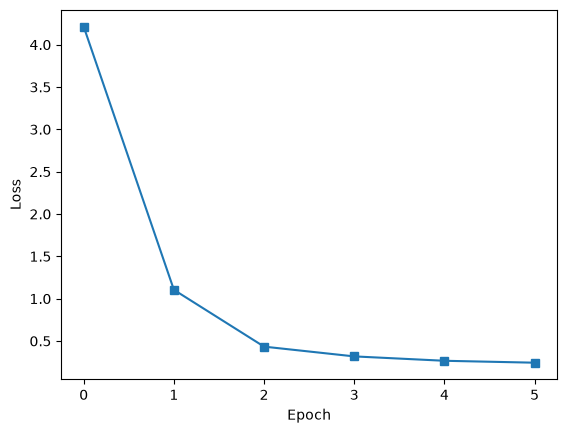

In [85]:
# check out the losses
plt.plot(losses,'s-')
plt.xlabel('Epoch')
plt.ylabel('Loss')

In [86]:
# Rand
seed = [
    [20, 54, 0],    # F3, bass
    [33, 34, 40],   # G4, 16th
    [37, 34, 40],   # B4, 16th
    [38, 46, 40],   # C5, 8th
    [33, 46, 40],   # G4

]

seed = np.array(seed)

In [87]:
generated = generate_midi(
    model=deepStrum,
    seed_sequence=seed,
    num_notes=200,
    pitch_idx_to_value=idx_to_pitch,
    duration_idx_to_value=idx_to_duration,
    step_idx_to_value=idx_to_step,
    output_file="Output/generated_guarania.mid",
    bpm=84,
    top_k=5,
    device=device
)

Generated MIDI saved to: Output/generated_guarania.mid


In [88]:
torch.save({
    'model_state_dict': deepStrum.state_dict(),

    # Model architecture
    'hidden_size': hidden_size,
    'num_layers': num_layers,

    # Vocabulary sizes
    'pitch_vocab_size': pitch_vocab_size,
    'duration_vocab_size': duration_vocab_size,
    'step_vocab_size': step_vocab_size,

    # Vocabulary mappings
    'idx_to_pitch': idx_to_pitch,
    'idx_to_duration': idx_to_duration,
    'idx_to_step': idx_to_step,

    # Training information
    'seq_length': seq_length,
}, 'Output/DeepStrum_guarania.pth')

print("Model saved!")

Model saved!
